# Importing Libraries

In [1]:
# ========== Standard Library Imports ==========
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress INFO/WARNING logs
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Reduce plugin loading issues

# ========== Data Handling & Visualization ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# ========== Scikit-learn Tools for Evaluation & Preprocessing ==========
from sklearn.metrics import confusion_matrix, classification_report, auc, precision_recall_curve, precision_score, recall_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ========== TensorFlow / Keras for Deep Learning ==========
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, SimpleRNN, Dropout, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

E0000 00:00:1750666029.344888      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750666029.408697      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load Dataset

In [2]:
train_dir = pd.read_csv('/kaggle/input/twitter_training.csv')
test_dir = pd.read_csv('/kaggle/input/twitter_validation.csv')
columns = ['Tweet ID', 'entity', 'sentiment', 'Tweet content']

train_dir.columns = columns
test_dir.columns = columns

# Train Dataset

In [3]:
train_dir.head()

,Tweet ID,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
train_dir.tail()

,Tweet ID,entity,sentiment,Tweet content
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...
74680,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


In [5]:
train_dir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet ID       74681 non-null  int64 
 1   entity         74681 non-null  object
 2   sentiment      74681 non-null  object
 3   Tweet content  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
train_dir.describe()

,Tweet ID
count,74681.000000
mean,6432.640149
std,3740.423819
min,1.000000
25%,3195.000000
50%,6422.000000
75%,9601.000000
max,13200.000000


In [7]:
train_dir.shape

(74681, 4)

In [8]:
train_dir.columns

Index(['Tweet ID', 'entity', 'sentiment', 'Tweet content'], dtype='object')

In [9]:
train_dir.isnull().sum()

Tweet ID           0
entity             0
sentiment          0
Tweet content    686
dtype: int64

In [10]:
train_dir.duplicated().sum()
train_dir.drop_duplicates(inplace=True)

In [11]:
train_dir.drop(columns=['Tweet ID'], inplace=True)
train_dir

,entity,sentiment,Tweet content
0,Borderlands,Positive,I am coming to the borders and I will kill you...
1,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,Borderlands,Positive,im coming on borderlands and i will murder you...
3,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...
74676,Nvidia,Positive,Just realized that the Windows partition of my...
74677,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,Nvidia,Positive,Just realized between the windows partition of...


In [12]:
train_dir['entity'].value_counts()

entity
TomClancysRainbowSix                 2344
Verizon                              2328
MaddenNFL                            2324
CallOfDuty                           2322
Microsoft                            2319
NBA2K                                2306
WorldOfCraft                         2304
LeagueOfLegends                      2303
TomClancysGhostRecon                 2301
Facebook                             2293
ApexLegends                          2289
Battlefield                          2267
Amazon                               2264
johnson&johnson                      2261
CallOfDutyBlackopsColdWar            2261
FIFA                                 2245
Overwatch                            2229
Dota2                                2229
Hearthstone                          2227
HomeDepot                            2226
Xbox(Xseries)                        2222
GrandTheftAuto(GTA)                  2214
Nvidia                               2211
Google                     

In [13]:
train_dir['sentiment'].value_counts()

sentiment
Negative      21787
Positive      19810
Neutral       17800
Irrelevant    12584
Name: count, dtype: int64

In [14]:
train_dir = train_dir[train_dir['sentiment'] != 'Irrelevant']

In [15]:
train_dir['sentiment'].value_counts()

sentiment
Negative    21787
Positive    19810
Neutral     17800
Name: count, dtype: int64

In [16]:
train_dir['Tweet content'].isnull().sum()

279

In [17]:
train_dir.dropna(subset=['Tweet content'], inplace=True)

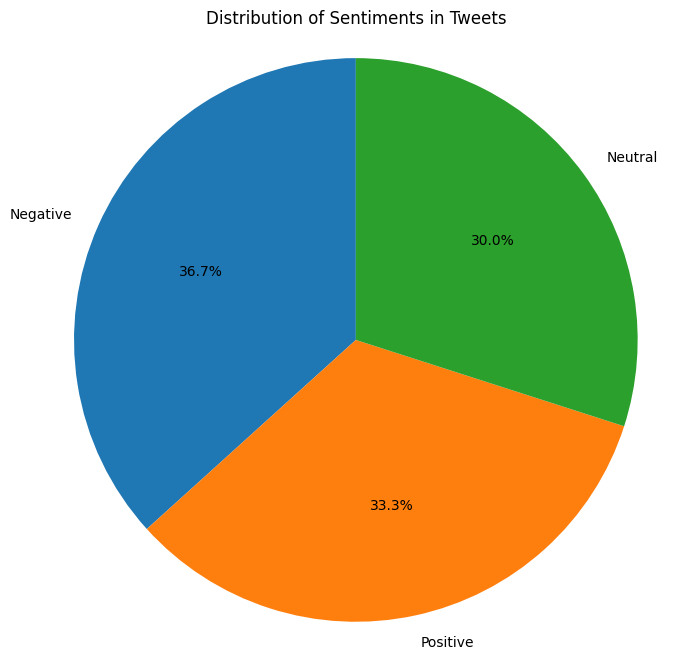

In [18]:
sentiment_counts = train_dir['sentiment'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Sentiments in Tweets')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Test Dataset

In [19]:
test_dir.head()

,Tweet ID,entity,sentiment,Tweet content
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [20]:
test_dir.tail()

,Tweet ID,entity,sentiment,Tweet content
994,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
995,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
996,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
997,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.
998,6960,johnson&johnson,Neutral,Johnson & Johnson to stop selling talc baby po...


In [21]:
test_dir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet ID       999 non-null    int64 
 1   entity         999 non-null    object
 2   sentiment      999 non-null    object
 3   Tweet content  999 non-null    object
dtypes: int64(1), object(3)
memory usage: 31.3+ KB


In [22]:
test_dir.describe()

,Tweet ID
count,999.000000
mean,6435.159159
std,3728.912226
min,6.000000
25%,3241.500000
50%,6560.000000
75%,9662.500000
max,13197.000000


In [23]:
test_dir.shape

(999, 4)

In [24]:
test_dir.columns

Index(['Tweet ID', 'entity', 'sentiment', 'Tweet content'], dtype='object')

In [25]:
test_dir.isnull().sum()

Tweet ID         0
entity           0
sentiment        0
Tweet content    0
dtype: int64

In [26]:
test_dir.duplicated().sum()
test_dir.drop_duplicates(inplace=True)

In [27]:
test_dir.drop(columns=['Tweet ID'], inplace=True)
test_dir

,entity,sentiment,Tweet content
0,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Google,Neutral,Now the President is slapping Americans in the...
4,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...,...
994,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
995,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
996,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
997,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [28]:
test_dir['entity'].value_counts()

entity
RedDeadRedemption(RDR)               40
johnson&johnson                      39
PlayerUnknownsBattlegrounds(PUBG)    38
FIFA                                 38
LeagueOfLegends                      37
ApexLegends                          36
Nvidia                               35
TomClancysRainbowSix                 35
GrandTheftAuto(GTA)                  35
Amazon                               34
Fortnite                             34
PlayStation5(PS5)                    33
AssassinsCreed                       33
Borderlands                          33
Hearthstone                          32
CS-GO                                32
Facebook                             32
Overwatch                            32
Verizon                              32
CallOfDuty                           31
Cyberpunk2077                        30
WorldOfCraft                         30
MaddenNFL                            29
Microsoft                            28
Dota2                            

In [29]:
test_dir['sentiment'].value_counts()

sentiment
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64

In [30]:
test_dir = test_dir[test_dir['sentiment'] != 'Irrelevant']

In [31]:
test_dir['sentiment'].value_counts()

sentiment
Neutral     285
Positive    277
Negative    266
Name: count, dtype: int64

In [32]:
test_dir['Tweet content'].isnull().sum()

0

In [33]:
test_dir.dropna(subset=['Tweet content'], inplace=True)

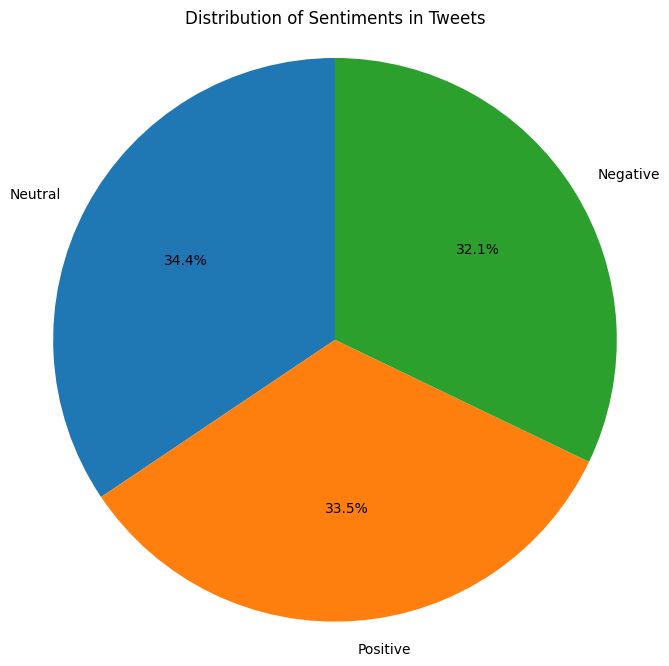

In [34]:
sentiment_counts = test_dir['sentiment'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Sentiments in Tweets')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Split 80% train, 20% validation

In [35]:
# Split 80% train, 20% validation, stratified by sentiment to keep class balance
train_data, val_data = train_test_split(
    train_dir,
    test_size=0.2,
    random_state=42,
    stratify=train_dir['sentiment']
)

# Text Preprocessing for Sentiment Analysis

## Hyperparameters for Text Tokenization and Padding

In [36]:
# Maximum number of words to keep based on word frequency
max_words = 5000

# Maximum length of each input sequence (in words); shorter sequences will be padded
max_len = 100

## Tokenization and Padding of Tweet Texts

In [37]:
# Initialize tokenizer
tokenizer = Tokenizer(num_words=max_words)

# Fit tokenizer on train texts only
tokenizer.fit_on_texts(train_data['Tweet content'])

# Convert texts to sequences
train_sequences = tokenizer.texts_to_sequences(train_data['Tweet content'])
val_sequences = tokenizer.texts_to_sequences(val_data['Tweet content'])
test_sequences = tokenizer.texts_to_sequences(test_dir['Tweet content'])

# Pad sequences to fixed length
train_padded = pad_sequences(train_sequences, maxlen=max_len)
val_padded = pad_sequences(val_sequences, maxlen=max_len)
test_padded = pad_sequences(test_sequences, maxlen=max_len)

## Data Preparation

In [38]:
# Assign padded tweet sequences to training features
X_train = train_padded

# Assign corresponding sentiment labels as training targets
y_train = train_data['sentiment']

# Assign padded tweet sequences to validation features
X_val = val_padded

# Assign corresponding sentiment labels as validation targets
y_val = val_data['sentiment']

# Assign padded tweet sequences to testing features (from test_dir)
X_test = test_padded

# Assign corresponding sentiment labels as testing targets
y_test = test_dir['sentiment']

## Encoding Sentiment Labels

In [39]:
# Create a LabelEncoder instance
le = LabelEncoder()

# Fit label encoder on train labels only
y_train = le.fit_transform(train_data['sentiment'])
y_val = le.transform(val_data['sentiment'])
y_test = le.transform(test_dir['sentiment'])

# Convert labels to categorical (one-hot)
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

# Model Phase

## RNN Model

In [40]:
# Clear Backend Session
tf.keras.backend.clear_session()

# Model Build
model = Sequential([
    # Embedding layer to convert word indices into dense vectors of fixed size
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),

    # Bidirectional SimpleRNN to capture context from both past and future
    # L2 regularization is used to prevent overfitting
    Bidirectional(SimpleRNN(64, return_sequences=False, kernel_regularizer=l2(0.001))),

    # Dropout layer to randomly drop 60% of neurons during training for regularization
    Dropout(0.6),

    # Dense layer with ReLU activation and L2 regularization for learning non-linear features
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),

    # Additional Dropout layer to further reduce overfitting
    Dropout(0.5),

    # Output layer with softmax activation for multiclass classification (3 classes)
    Dense(3, activation='softmax')
])

# Define input shape for the model (batch_size=None, sequence_length=max_len)
model.build(input_shape=(None, max_len))

# Model Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

I0000 00:00:1750666046.860969      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750666046.861631      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 64)             │         320,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 344,963 (1.32 MB)

 Trainable params: 344,963 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## Early Stopping

In [41]:
# Early Stopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

## Train the model

In [42]:
history = model.fit(
    X_train,        # training features (padded sequences)
    y_train,        # training labels (one-hot encoded)
    validation_data=(X_val, y_val),  # validation features and labels
    epochs=30,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/30


I0000 00:00:1750666052.500298      61 service.cc:148] XLA service 0x3301b610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750666052.501063      61 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750666052.501084      61 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750666052.937205      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


 12/739 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3637 - loss: 1.3154

I0000 00:00:1750666055.183419      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


739/739 ━━━━━━━━━━━━━━━━━━━━ 22s 21ms/step - accuracy: 0.4340 - loss: 1.2078 - val_accuracy: 0.7120 - val_loss: 0.7610
Epoch 2/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7558 - loss: 0.6810 - val_accuracy: 0.7789 - val_loss: 0.6026
Epoch 3/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8411 - loss: 0.4688 - val_accuracy: 0.8177 - val_loss: 0.5125
Epoch 4/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8902 - loss: 0.3445 - val_accuracy: 0.8234 - val_loss: 0.5043
Epoch 5/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9105 - loss: 0.2857 - val_accuracy: 0.8217 - val_loss: 0.5274
Epoch 6/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9210 - loss: 0.2498 - val_accuracy: 0.8160 - val_loss: 0.5909
Epoch 7/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9269 - loss: 0.2361 - val_accuracy: 0.8262 - val_loss: 0.5555
Epoch 8/30
739/739 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9388 - loss: 0.2027 - val_accurac

# Model Training Metrics

## Evaluate the model

In [43]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9015 - loss: 0.3411
Test Loss: 0.3449
Test Accuracy: 89.73%


## Model (Accuracy and Loss)

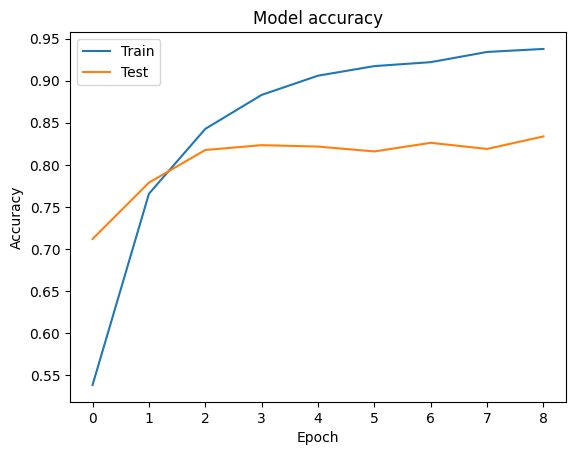

In [44]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

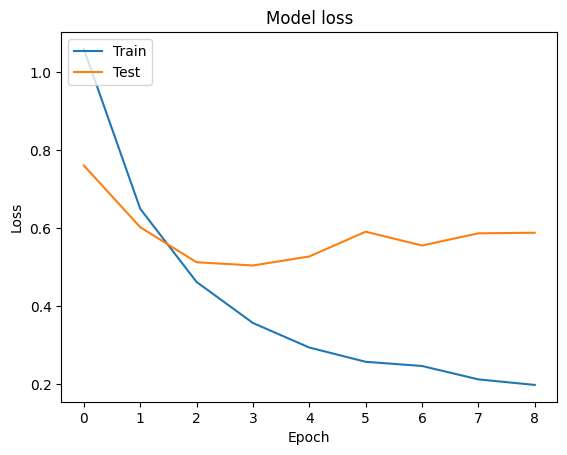

In [45]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

## Predictions on test set

In [46]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Convert predicted probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


## Classification Report


In [47]:
print("Classification Report:\n", classification_report(y_true, y_pred_classes))

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       266
           1       0.91      0.87      0.89       285
           2       0.87      0.91      0.89       277

    accuracy                           0.90       828
   macro avg       0.90      0.90      0.90       828
weighted avg       0.90      0.90      0.90       828



## Confusion Matrix

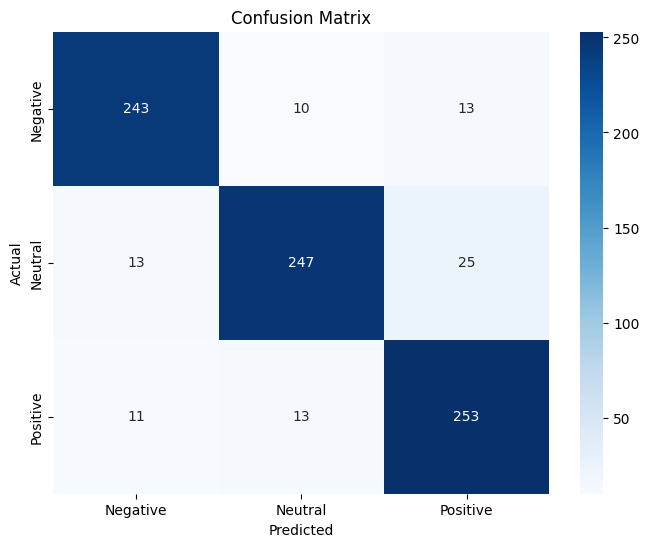

In [48]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Receiver Operating Characteristic (ROC) Curves

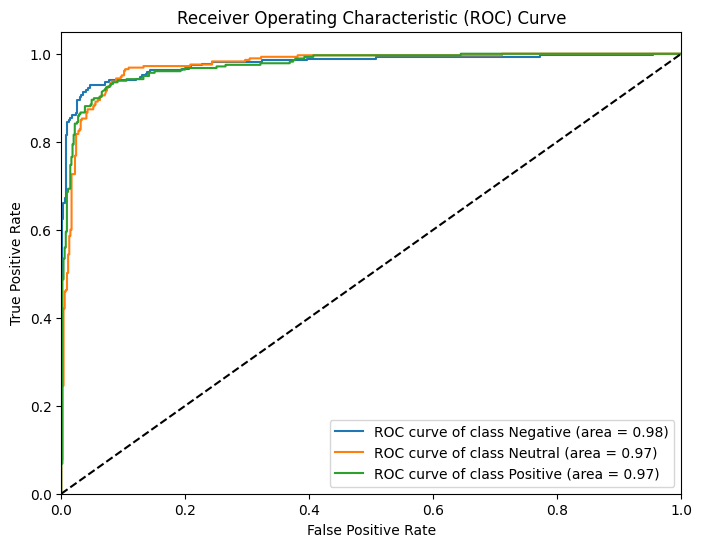

In [49]:
fpr = dict()
tpr = dict()
roc_auc = dict()

# Convert y_test to a one-hot encoded format suitable for roc_curve
y_test_roc = np.argmax(y_test, axis=1)
# Get the number of classes from the shape of y_test
num_classes = y_test.shape[1] # assign num_classes
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_roc == i, y_pred[:, i]) # Modify roc_curve call
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {le.classes_[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Precision-Recall Curve

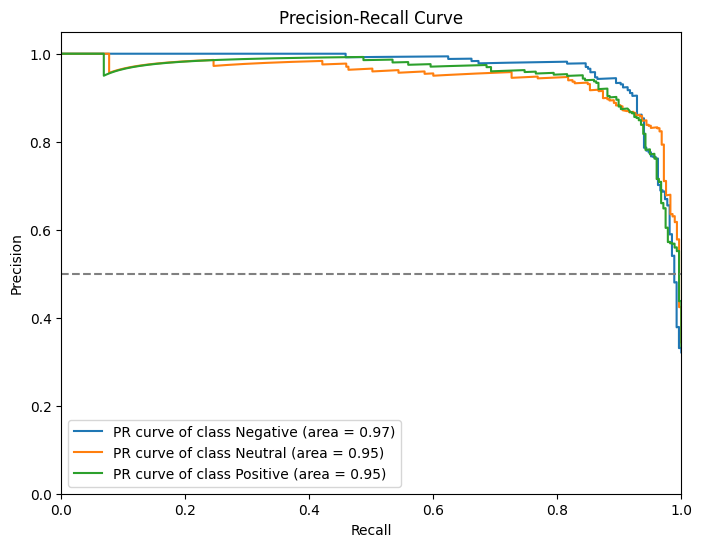

In [50]:
precision = dict()
recall = dict()
pr_auc = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_roc == i, y_pred[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

#Plot Precision-Recall curve for each class
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], label=f'PR curve of class {le.classes_[i]} (area = {pr_auc[i]:0.2f})')

plt.plot([0, 1], [0.5, 0.5], linestyle='--', color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Model Test

In [51]:
new_tweets = ["This is great!", "This is bad!", "go to bed early!"]

# Preprocess the new tweets
new_sequences = tokenizer.texts_to_sequences(new_tweets)
new_padded = pad_sequences(new_sequences, maxlen=max_len)

# Make predictions
new_predictions = model.predict(new_padded)

# Convert probabilities to class labels
new_predicted_classes = np.argmax(new_predictions, axis=1)

# Get the sentiment labels
predicted_sentiments = le.inverse_transform(new_predicted_classes)

# Print the predicted sentiments
for tweet, sentiment in zip(new_tweets, predicted_sentiments):
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment: {sentiment}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step
Tweet: This is great!
Predicted Sentiment: Positive

Tweet: This is bad!
Predicted Sentiment: Negative

Tweet: go to bed early!
Predicted Sentiment: Positive



# Save Model

In [52]:
model.save(f'sentiment_analysis_model{accuracy * 100:.2f}acc.h5')